In [1]:
import scMPRAforge as scm
from dask.distributed import Client, LocalCluster
from pathlib import Path
import pandas as pd

2025-11-18 10:59:26.921601: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-18 10:59:26.926184: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /vast/palmer/apps/avx2/software/code-server/4.91.1/lib:/vast/palmer/apps/avx2/software/gettext/0.22.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libiconv/1.17-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/ncurses/6.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/XZ/5.4.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/expat/2.6.2-GCCcore-13.3.0/lib:/vast/palmer/apps/av

In [2]:
DATA_ROOT=Path("/gpfs/gibbs/pi/reilly/tabula_data")
path=DATA_ROOT/"simulated"
name="shendure_calibrated_sim_with_orthos_20251116"

In [3]:
cluster = LocalCluster(memory_limit='48G')
client = Client(cluster)

In [4]:
simu_obj=scm.de_novo_simulation.load(client,path=path,name=name)

In [5]:
ex_ground_truth=simu_obj.ground_truth

In [6]:
def load_result(root: Path, hypothesis: str, test: str, replicate: int) -> pd.DataFrame:
    """Load a TSV result from the given directory structure."""
    path = root / hypothesis / test / str(replicate)
    if not path.exists():
        raise FileNotFoundError(f"No such file: {path}")
    return pd.read_csv(path, sep='\t')

In [7]:
def merge_in_ground_truth(results,ground_truth):    
        merged=results.merge(ground_truth,
            left_on=["comparison_CRE","comparison_cell_type"],
            right_on=["cre_id","cell_type"]
        )
        
        merged=merged.drop(columns=["cre_id","cell_type"])
        merged=merged.rename({"true_mean":"comparison_truth"},axis=1)

        #merge in `reference` ground truth
        merged=merged.merge(ground_truth,
            left_on=["reference_CRE","reference_cell_type"],
            right_on=["cre_id","cell_type"]
        )
        merged=merged.drop(columns=["cre_id","cell_type"])
        merged=merged.rename({"true_mean":"reference_truth"},axis=1)

        #ground truth effect size
        merged["gt_effect_size"]=merged["comparison_truth"]/merged["reference_truth"]
        #ground truth null hypothesis that the CREs are the same : true or false?
        merged["gt_null"]=abs(merged["gt_effect_size"]-1)<1e-8

        merged["reject_null"]=merged["bh_p"]<0.05

        #godawful hack
        #merged=merged.dropna(subset=["p_value"])

        return merged

In [8]:
ground_truth=simu_obj.ground_truth

records = []

for test in ["mwu", "wald"]:
    for hypothesis_set in ["hs_all_cre", "hs_all_ct"]:
        for replicate in range(5):
            ex = load_result(root=path/name/"results",
                                hypothesis=hypothesis_set,
                                test=test,
                                replicate=replicate)
            ex_merged = merge_in_ground_truth(results=ex,
                                                ground_truth=ex_ground_truth)
            ct = pd.crosstab(ex_merged["gt_null"], ex_merged["reject_null"])
            # Flatten the crosstab into a dict of counts
            for (gt, reject), count in ct.stack().items():
                records.append({
                    "test": test,
                    "hypothesis_set": hypothesis_set,
                    "replicate": replicate,
                    "gt_null": gt,
                    "reject_null": reject,
                    "count": count
                })

df = pd.DataFrame(records)
summary = (df.groupby(["test", "hypothesis_set", "gt_null", "reject_null"])
                ["count"]
                .agg(["mean", "std", "sum", "count"])
                .reset_index())

In [9]:
summary

,test,hypothesis_set,gt_null,reject_null,mean,std,sum,count
0,mwu,hs_all_cre,False,False,186.0,8.455767,930,5
1,mwu,hs_all_cre,False,True,1060.0,8.455767,5300,5
2,mwu,hs_all_ct,False,False,206.8,10.639549,1034,5
3,mwu,hs_all_ct,False,True,1245.2,10.639549,6226,5
4,wald,hs_all_cre,False,False,225.8,14.394443,1129,5
5,wald,hs_all_cre,False,True,1020.2,14.394443,5101,5
6,wald,hs_all_ct,False,False,195.0,10.816654,975,5
7,wald,hs_all_ct,False,True,1257.0,10.816654,6285,5


In [10]:
records = []
for test in ["mwu", "wald"]:
    for hypothesis_set in ["hs_all_cre", "hs_all_ct"]:
        correct_fracs = []
        for replicate in range(5):
            ex = load_result(root=path/name/"results",
                                hypothesis=hypothesis_set,
                                test=test,
                                replicate=replicate)
            ex_merged = merge_in_ground_truth(results=ex,
                                                ground_truth=ex_ground_truth)

            # since gt_null is always False, "correct" means reject_null == True
            frac_correct = (ex_merged["reject_null"] == True).mean()
            correct_fracs.append(frac_correct)

        records.append({
            "test": test,
            "hypothesis_set": hypothesis_set,
            "mean_fraction_correct": pd.Series(correct_fracs).mean(),
            "std_fraction_correct": pd.Series(correct_fracs).std(),
        })

pd.DataFrame(records)

,test,hypothesis_set,mean_fraction_correct,std_fraction_correct
0,mwu,hs_all_cre,0.850722,0.006786
1,mwu,hs_all_ct,0.857576,0.007328
2,wald,hs_all_cre,0.818780,0.011553
3,wald,hs_all_ct,0.865702,0.007449


In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_p_vs_effect(hypothesis_set, test, replicate, cell_type = None):
    ex = load_result(root=path/name/"results",
                     hypothesis=hypothesis_set,
                     test=test,
                     replicate=replicate)
    if cell_type is not None:
        ex = ex[ex['comparison_cell_type']==cell_type]

    df = merge_in_ground_truth(results=ex, ground_truth=ex_ground_truth)

    # compute color by log10(max of comparison_truth and reference_truth)
    df["log_max_activity"] = np.log10(np.maximum(df["comparison_truth"], df["reference_truth"]).clip(lower=1e-12))

    # use a reversed warm colormap (small = red/yellow, large = blue)
    sns.scatterplot(data=df, x="gt_effect_size", y="p_value", hue="log_max_activity",
                    palette="inferno_r", alpha=0.6)

    plt.xscale("log")
    plt.yscale("log")
    plt.xlim(1e-2, 1e4)
    plt.ylim(1e1, 1e-310)

    plt.xlabel("Ground Truth Effect Size (log scale)")
    plt.ylabel("p-value (log scale)")
    plt.legend(title="log10(Max Activity)")
    plt.title(f"p-value vs Ground Truth Effect Size\n(test={test}, hypothesis_set={hypothesis_set}, replicate={replicate})")
    plt.tight_layout()
    plt.show()


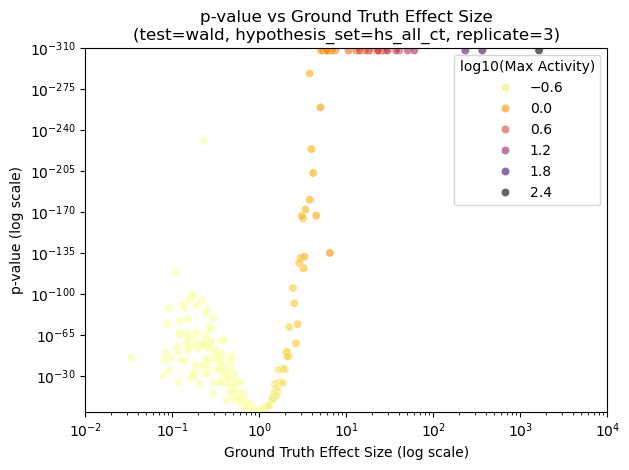

In [59]:
plot_p_vs_effect(hypothesis_set="hs_all_ct",test="wald",replicate='3', cell_type = 'reference')

In [50]:
ex.comparison_cell_type.unique()

array(['Cardiomyocytes', 'EpiblastPrimitiveStreak', 'ExEndodermParietal',
       'ExEndodermVisceral', 'Haematoendothelial', 'Mesoderm',
       'NeuroectodermBrain', 'NeuroectodermRostral', 'SurfaceEctoderm',
       'reference'], dtype=object)

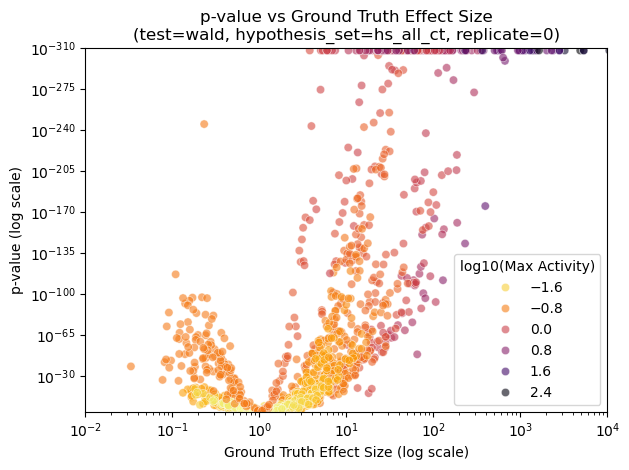

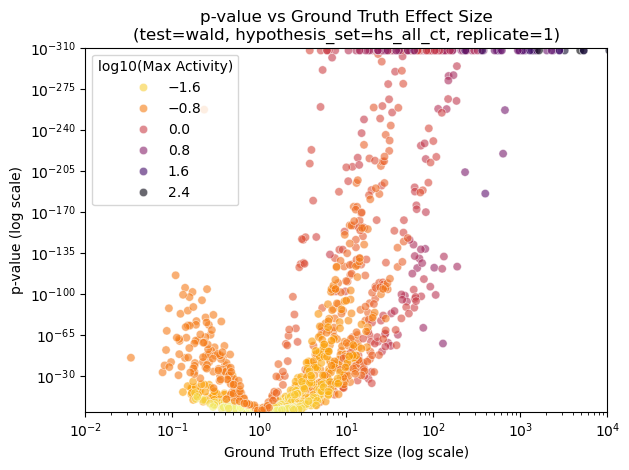

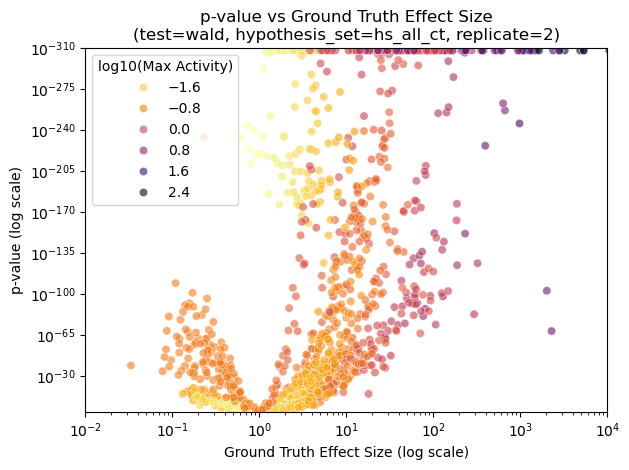

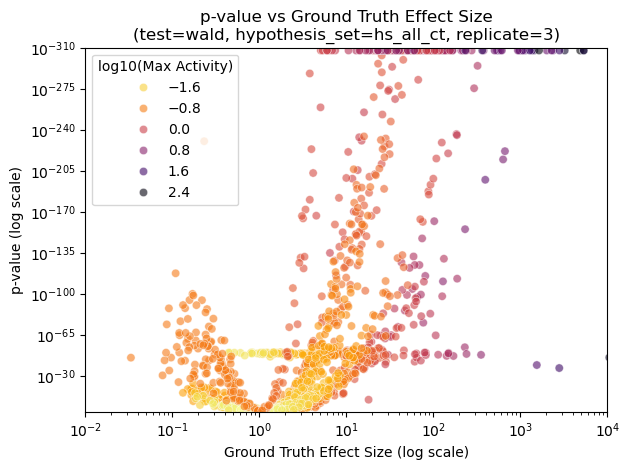

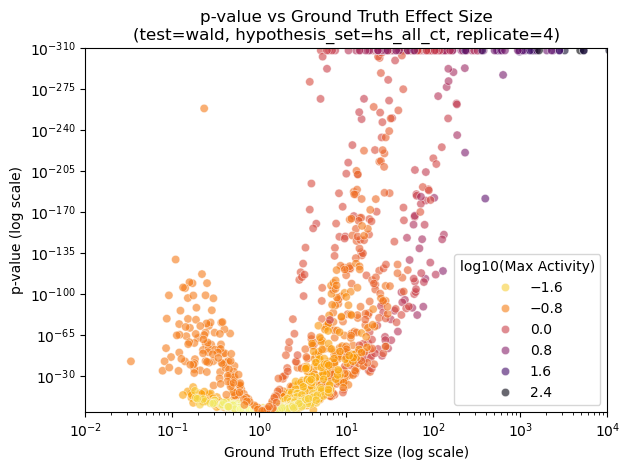

In [12]:
for replicate in range(5):
    plot_p_vs_effect(hypothesis_set="hs_all_ct",test="wald",replicate=replicate)

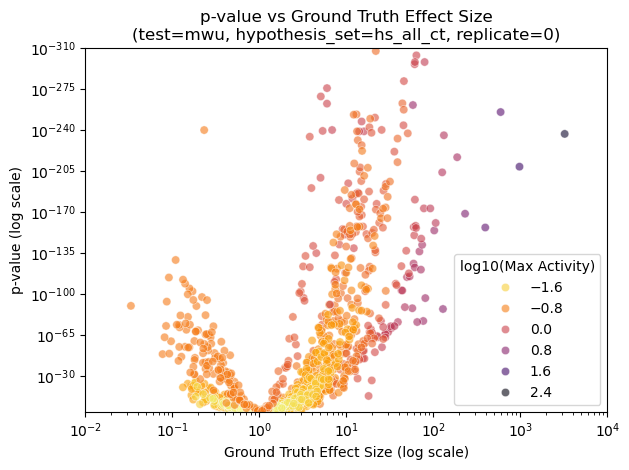

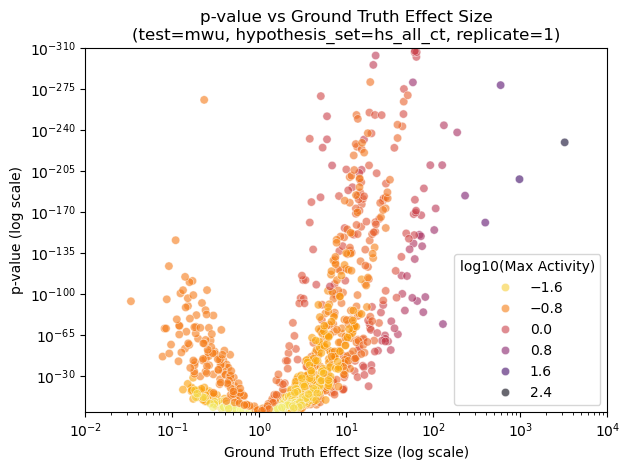

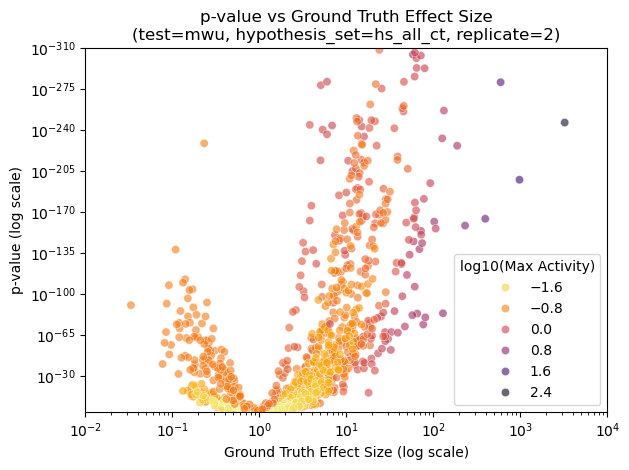

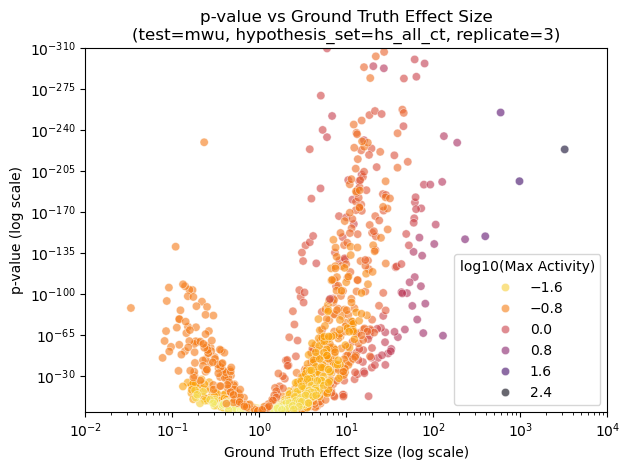

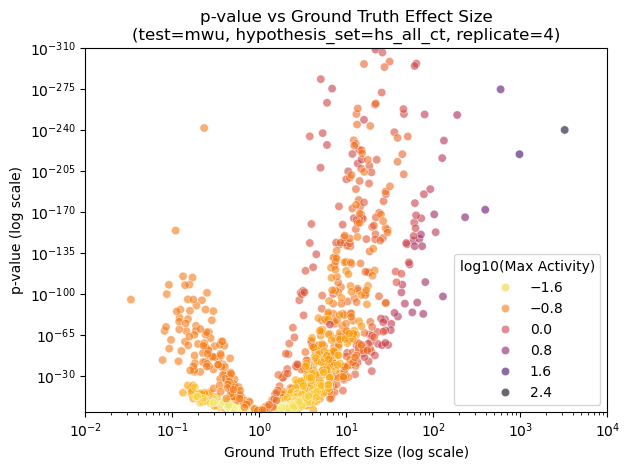

In [13]:
for replicate in range(5):
    plot_p_vs_effect(hypothesis_set="hs_all_ct",test="mwu",replicate=replicate)

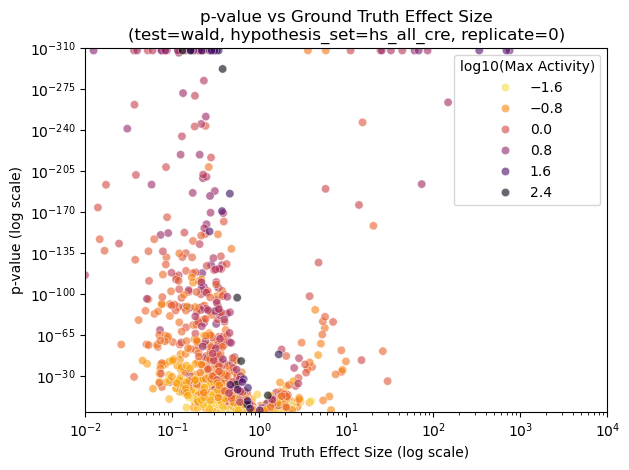

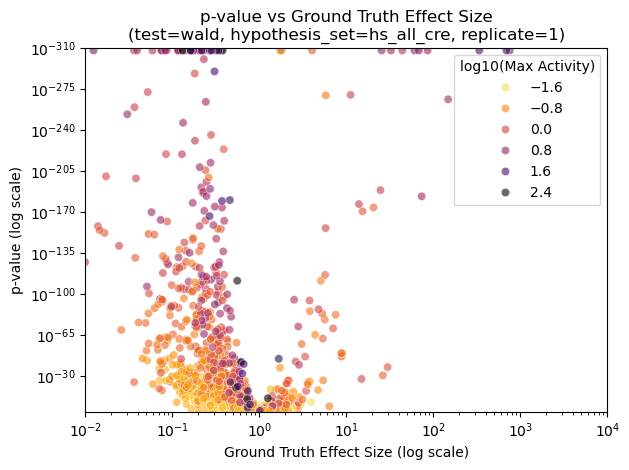

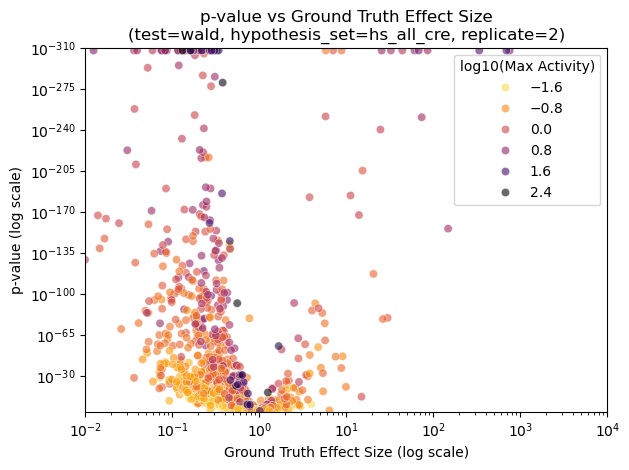

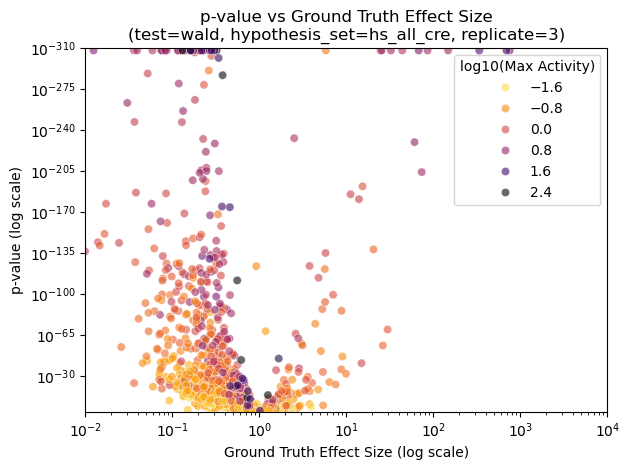

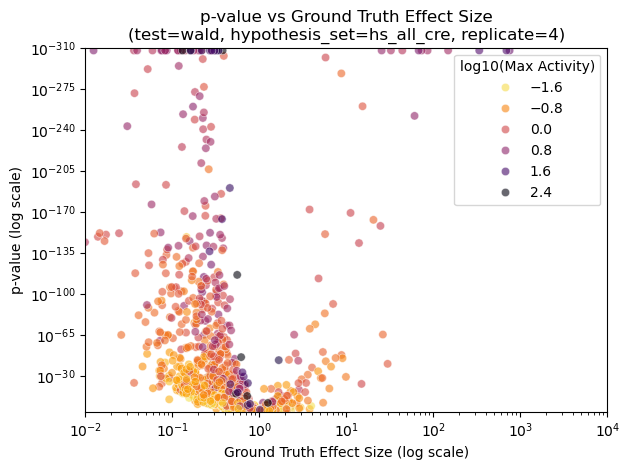

In [14]:
for replicate in range(5):
    plot_p_vs_effect(hypothesis_set="hs_all_cre",test="wald",replicate=replicate)

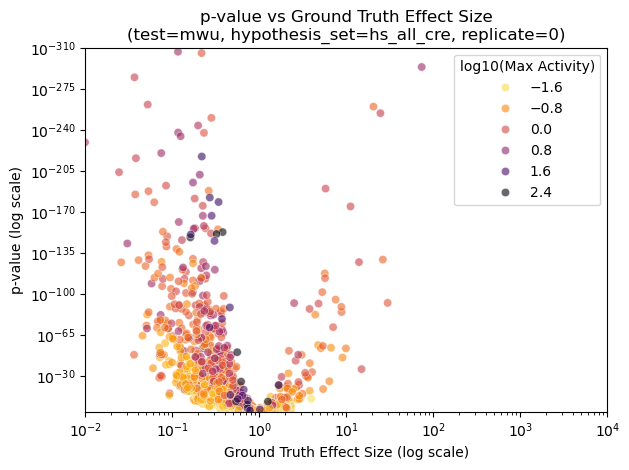

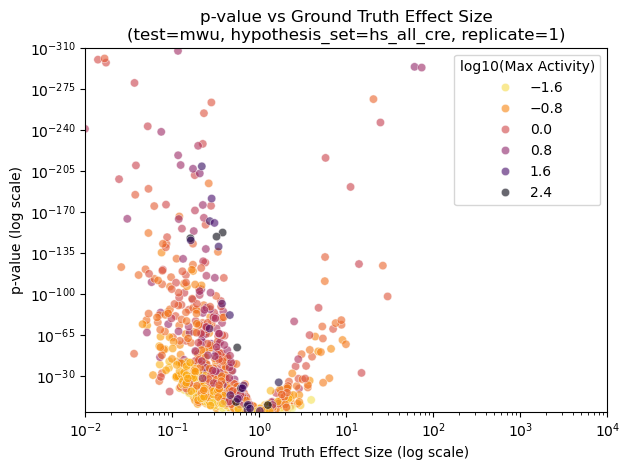

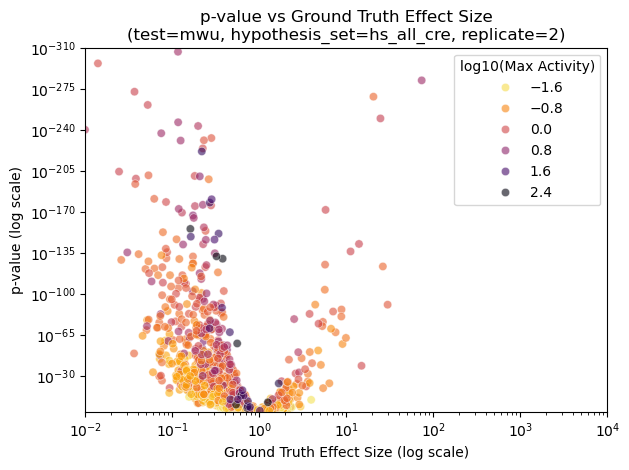

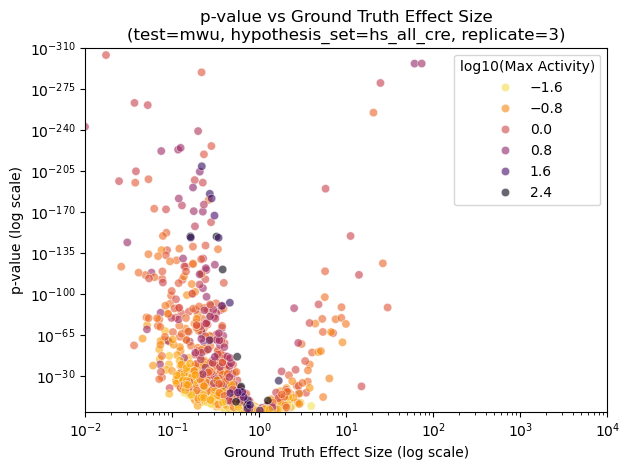

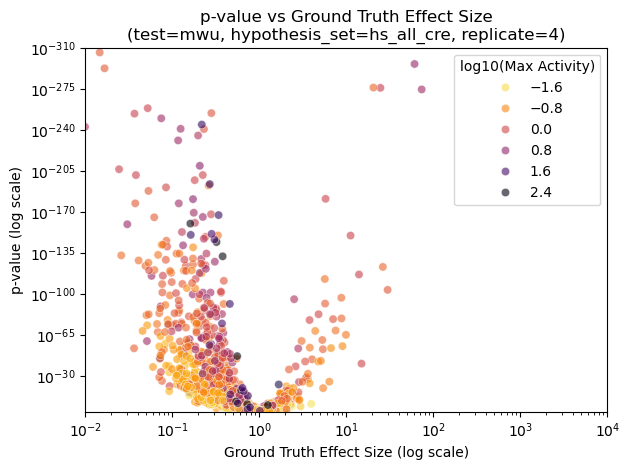

In [15]:
for replicate in range(5):
    plot_p_vs_effect(hypothesis_set="hs_all_cre",test="mwu",replicate=replicate)

In [75]:
ex = load_result(root=path/name/"results",
                     hypothesis="hs_all_ct",
                     test="wald",
                     replicate=3)
df = merge_in_ground_truth(results=ex, ground_truth=ex_ground_truth)

In [76]:
df[df.comparison_cell_type =='ExEndodermVisceral']

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,wald_debug,test_type,bh_p,comparison_truth,reference_truth,gt_effect_size,gt_null,reject_null
439,Cdk5r1_chr11_12575,ExEndodermVisceral,reference,ExEndodermVisceral,emvar_screen,-14.711911,5.405864e-49,7.998989e-60,False,ok,wald,1.464424e-48,0.029786,0.016063,1.854283,False,True
440,Cited2_chr10_1267,ExEndodermVisceral,reference,ExEndodermVisceral,emvar_screen,-14.850633,6.891495e-50,5.223261e-60,False,ok,wald,2.067449e-49,0.021850,0.016063,1.360205,False,True
441,Col1a1_chr11_15259,ExEndodermVisceral,reference,ExEndodermVisceral,emvar_screen,-14.911641,2.768637e-50,2.213356e-60,False,ok,wald,8.499071e-50,0.009788,0.016063,0.609340,False,True
442,Col5a1_chr2_2558,ExEndodermVisceral,reference,ExEndodermVisceral,emvar_screen,-15.001719,7.154247e-51,4.332681e-60,False,ok,wald,2.329140e-50,0.013280,0.016063,0.826702,False,True
443,Epas1_chr17_10061,ExEndodermVisceral,reference,ExEndodermVisceral,emvar_screen,-14.730086,4.131811e-49,2.543354e-59,False,ok,wald,1.134100e-48,0.089420,0.016063,5.566670,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581,Cdk5r1_chr11_12574,ExEndodermVisceral,reference,ExEndodermVisceral,emvar_screen,-14.771321,2.242743e-49,8.730990e-58,False,ok,wald,6.310975e-49,3.873514,0.016063,241.138302,False,True
582,Sparc_chr11_7213,ExEndodermVisceral,reference,ExEndodermVisceral,emvar_screen,-14.908401,2.906308e-50,3.610602e-60,False,ok,wald,8.902867e-50,0.018021,0.016063,1.121893,False,True
583,Txndc12_chr4_7969,ExEndodermVisceral,reference,ExEndodermVisceral,emvar_screen,-14.513574,9.940375e-48,2.276997e-59,False,ok,wald,2.501460e-47,0.071268,0.016063,4.436663,False,True
584,Sox17_chr1_65,ExEndodermVisceral,reference,ExEndodermVisceral,emvar_screen,-14.994841,7.935241e-51,6.512367e-60,False,ok,wald,2.566140e-50,0.023695,0.016063,1.475096,False,True


In [74]:
df[df.comparison_cell_type =='ExEndodermVisceral']

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,wald_debug,test_type,bh_p,comparison_truth,reference_truth,gt_effect_size,gt_null,reject_null
439,Cdk5r1_chr11_12575,ExEndodermVisceral,reference,ExEndodermVisceral,emvar_screen,3.636380,2.764965e-04,1.850142,False,ok,wald,3.616874e-04,0.029786,0.016063,1.854283,False,True
440,Cited2_chr10_1267,ExEndodermVisceral,reference,ExEndodermVisceral,emvar_screen,0.649301,5.161442e-01,1.137320,False,ok,wald,5.387788e-01,0.021850,0.016063,1.360205,False,False
441,Col1a1_chr11_15259,ExEndodermVisceral,reference,ExEndodermVisceral,emvar_screen,-2.984086,2.844267e-03,0.416115,False,ok,wald,3.544957e-03,0.009788,0.016063,0.609340,False,True
442,Col5a1_chr2_2558,ExEndodermVisceral,reference,ExEndodermVisceral,emvar_screen,-1.278644,2.010225e-01,0.762419,False,ok,wald,2.196273e-01,0.013280,0.016063,0.826702,False,False
443,Epas1_chr17_10061,ExEndodermVisceral,reference,ExEndodermVisceral,emvar_screen,11.611250,3.612929e-31,5.445546,False,ok,wald,8.447622e-31,0.089420,0.016063,5.566670,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581,Cdk5r1_chr11_12574,ExEndodermVisceral,reference,ExEndodermVisceral,emvar_screen,39.266878,2.225074e-308,239.097517,False,ok,wald,2.447581e-307,3.873514,0.016063,241.138302,False,True
582,Sparc_chr11_7213,ExEndodermVisceral,reference,ExEndodermVisceral,emvar_screen,-1.581588,1.137436e-01,0.585900,False,ok,wald,1.263201e-01,0.018021,0.016063,1.121893,False,False
583,Txndc12_chr4_7969,ExEndodermVisceral,reference,ExEndodermVisceral,emvar_screen,4.894723,9.844410e-07,4.136318,False,ok,wald,1.461563e-06,0.071268,0.016063,4.436663,False,True
584,Sox17_chr1_65,ExEndodermVisceral,reference,ExEndodermVisceral,emvar_screen,1.407685,1.592244e-01,1.474853,False,ok,wald,1.755458e-01,0.023695,0.016063,1.475096,False,False


Text(0, 0.5, 'Estimated FC')

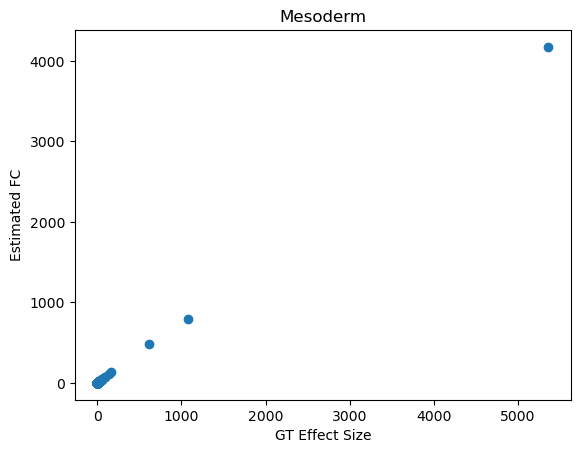

In [72]:
cell_type= 'Mesoderm'
plt.scatter(df[df.comparison_cell_type ==cell_type].gt_effect_size, df[df.comparison_cell_type ==cell_type].fold_change)
plt.title(cell_type)
plt.xlabel('GT Effect Size')
plt.ylabel('Estimated FC')

Text(0, 0.5, 'Estimated FC')

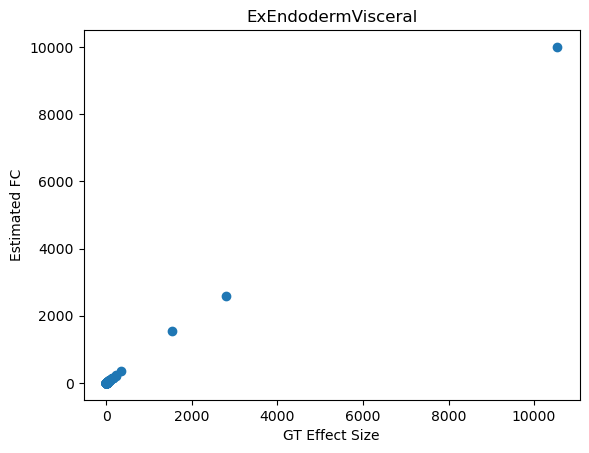

In [73]:
cell_type= 'ExEndodermVisceral'
plt.scatter(df[df.comparison_cell_type ==cell_type].gt_effect_size, df[df.comparison_cell_type =='ExEndodermVisceral'].fold_change)
plt.title(cell_type)
plt.xlabel('GT Effect Size')
plt.ylabel('Estimated FC')

In [39]:
df[df.isna().any(axis=1)]

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,wald_debug,test_type,bh_p,comparison_truth,reference_truth,gt_effect_size,gt_null,reject_null


In [47]:
ex2 = load_result(root=path/name/"results",
                     hypothesis="hs_all_cre",
                     test="wald",
                     replicate=1)
df2 = merge_in_ground_truth(results=ex2, ground_truth=ex_ground_truth)

In [48]:
df2[df2.isna().any(axis=1)]

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,wald_debug,test_type,bh_p,comparison_truth,reference_truth,gt_effect_size,gt_null,reject_null
846,Sox17_chr1_60,ExEndodermParietal,Sox17_chr1_60,reference,cell_specificity,NaN,NaN,NaN,False,no contrast term for ExEndodermParietal,wald,1.0,0.005472,0.05909,0.0926,False,False
1189,Txndc12_chr4_7969,ExEndodermParietal,Txndc12_chr4_7969,reference,cell_specificity,NaN,NaN,NaN,False,no contrast term for ExEndodermParietal,wald,1.0,0.154256,0.00000,inf,False,False


In [20]:
client.close()
cluster.close()